# Cross-Condition Analysis

In [ ]:
import plotnine as pn
import scanpy as sc
import matplotlib.pyplot as plt
from partipy.datasets import load_ncM_lupus_data
import decoupler as dc

import partipy as pt

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In this vignette, we focus on **non-classical monocytes** from {cite:p}`perezSinglecellRNAseqReveals2022`.

In this study, PBMCs from healthy subjects and from SLE (Systemic lupus erythematosus) patients were analyzed using scRNA-seq.

Here, we use the data to highlight how archetypal analysis can be used in the cross-condition setting. We identify one archetype that is enriched in the disease context, and characterize this archetype.

## Load Data


In [2]:
adata = load_ncM_lupus_data()
adata

AnnData object with n_obs × n_vars = 47819 × 30867
    obs: 'library_uuid', 'author_cell_type', 'sample_uuid', 'disease_state', 'donor_id', 'Processing_Cohort', 'ct_cov', 'ind_cov', 'cell_type', 'assay', 'disease', 'sex', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'Status'
    var: 'feature_is_filtered', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'

Check the number of cells we have per condition:

In [3]:
adata.obs.value_counts("Status")

Status
Managed    31268
Healthy    15091
Flare       1460
Name: count, dtype: int64

## Quality Control

We follow the Scanpy [tutorial](https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html) to perform quality control on the dataset.

First, we compute the proportion of counts originating from mitochondrial, ribosomal, and hemoglobin genes:

In [4]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains(("^HB[^(P)]"))

In [5]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)

We can now examine key quality control metrics, including:
- The number of genes expressed per cell
- The total counts per cell
- The percentage of counts originating from mitochondrial genes

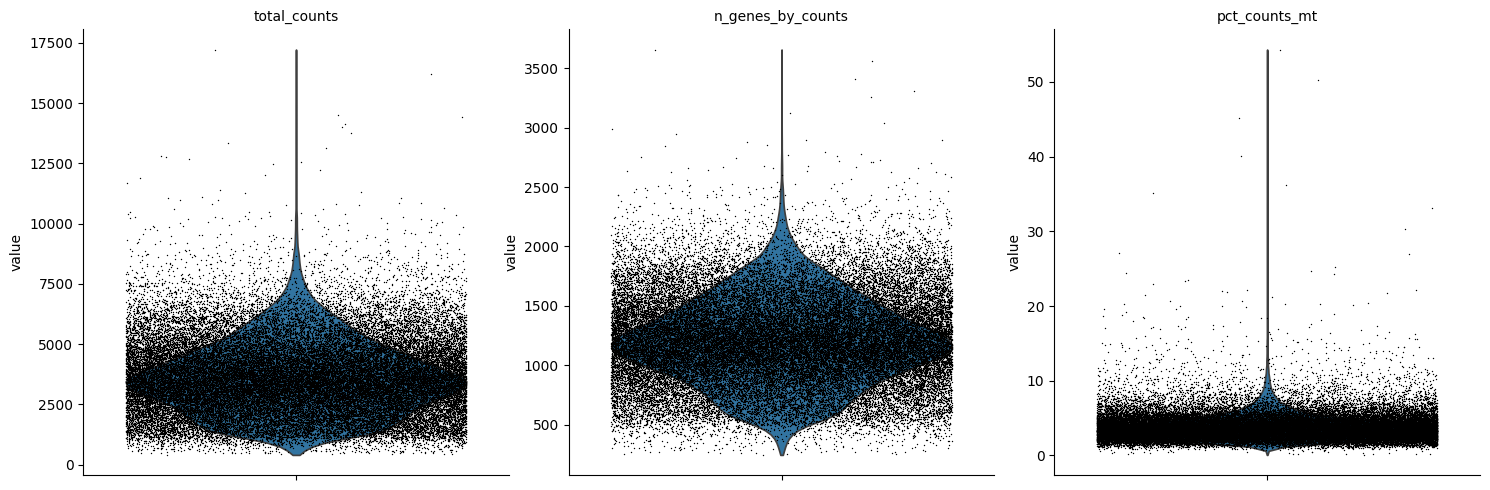

In [6]:
sc.pl.violin(
    adata,
    ["total_counts", "n_genes_by_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

To remove low-quality data, we filter out cells with fewer than 100 detected genes and genes that are present in fewer than 3 cells. This ensures that only high-quality cells and genes are retained for downstream analysis.

In [7]:
print(f"Number of cells before filtering: {adata.n_obs} \nNumber of genes before filtering: {adata.n_vars}")
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)
print(f"Number of cells after filtering of low quality cells: {adata.n_obs} \nNumber of genes after filtering of low quality genes: {adata.n_vars}")

Number of cells before filtering: 47819 
Number of genes before filtering: 30867


Number of cells after filtering of low quality cells: 47819 
Number of genes after filtering of low quality genes: 18496


## Normalization and feature selection

To ensure comparability across cells, we normalize the data to the median total counts per cell and apply a logarithmic transformation:

In [8]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

Next, we identify highly variable genes, which are key for downstream analysis. We also visualize them to assess their distribution:

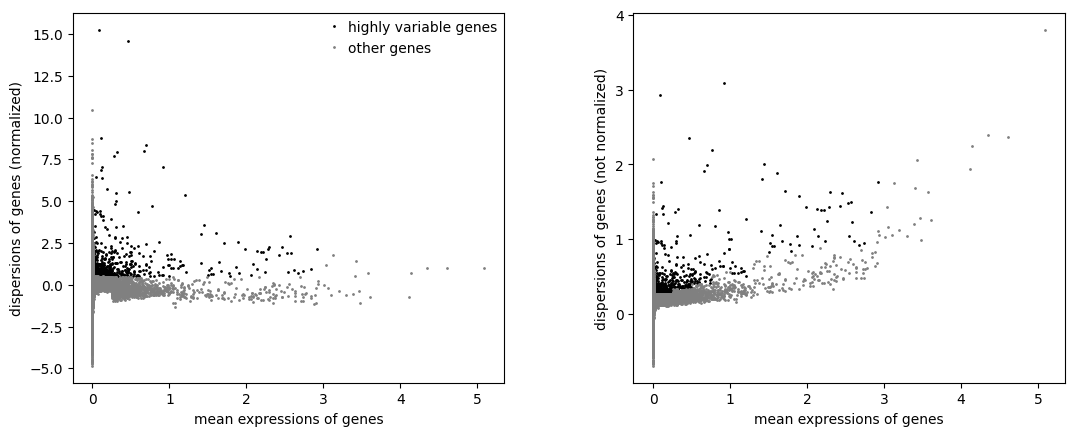

In [9]:
sc.pp.highly_variable_genes(adata)
sc.pl.highly_variable_genes(adata)

For the downstream enrichment analysis, we standardize the data by scaling gene expression values:

In [10]:
adata.layers["z_scaled"]= sc.pp.scale(adata.X, max_value=10, copy=True)

/Users/pschafer/miniforge3/envs/partipy/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.


## Dimension Reduction

We compute a Principal Component Analysis (PCA) using only highly variable genes to reduce nosie and extract the most meaningful dimensions based on explained variance.

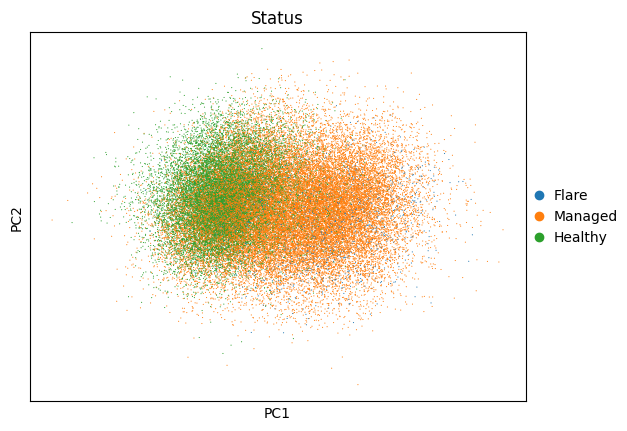

In [11]:
sc.pp.pca(adata, mask_var="highly_variable")
sc.pl.pca_scatter(adata, color="Status")

To determine the optimal number of principal components (PCs) to retain, we inspect their contribution to the total variance:

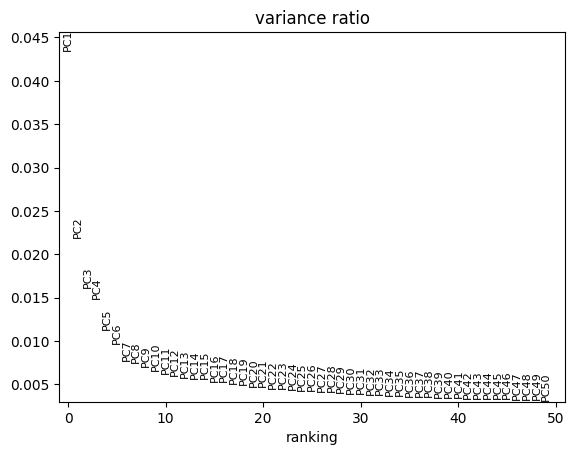

In [12]:
sc.pl.pca_variance_ratio(adata, n_pcs=50)

Based on this, we select 7 PCs, as the variance explained plateaus beyond this point. For ease of use in downstream analysis, we store the selected number of dimensions of the PCA in adata.uns["aa_config"] with the following function:

In [13]:
pt.set_obsm(adata=adata, obsm_key="X_pca", n_dimensions=7)

## Number of Archetypes

Next, we need to determine the optimal number of archetypes in our data—essentially, the number of vertices in the polyhedron.

We first assess how much variance is explained for different numbers of archetypes.

The function var_explained_aa() takes the 7D PCA data and calculates the explained variance for a range of archetypes (min_k to max_a). It computes:

- The variance explained by each archetype.
- The additional variance explained by each successive archetype.
- The distance from the projected point to the line of the elbow plot.
- An information criteria (IC)

In [14]:
pt.compute_selection_metrics(adata=adata, min_k=2, max_k=10)

The results are stored in:

In [15]:
adata.uns["AA_metrics"].head(10)

,k,seed,varexpl,IC
0,2,773956046,0.344210,44109.700304
1,2,438878439,0.344345,44390.978706
2,2,654571517,0.345081,41818.148964
3,2,89250953,0.344121,42078.851124
4,2,433015235,0.344908,41531.420645
5,3,773956046,0.512791,38391.991432
6,3,438878439,0.510987,39025.149923
7,3,654571517,0.509954,39130.206169
8,3,89250953,0.513245,38640.862373
9,3,433015235,0.512869,37192.327074


We visualize the explained variance for different models:

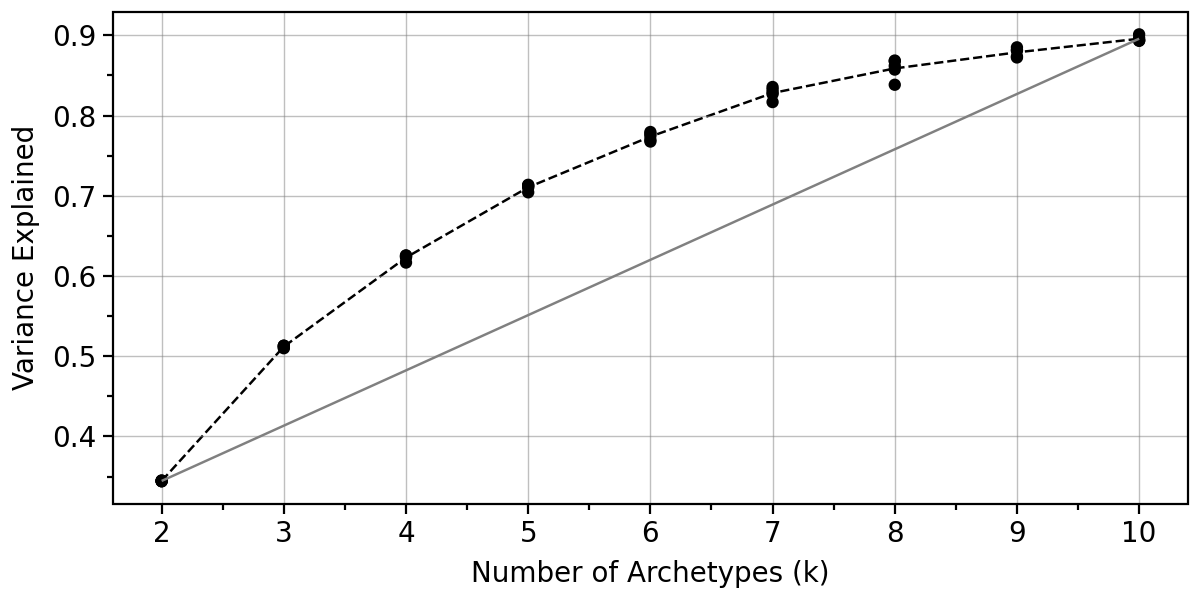

In [16]:
pt.plot_var_explained(adata)

In this plot, the grey line connects the first and last variance explained (EV) values, helping to identify the "elbow" of the black curve.

Visualize the trend of the IC:

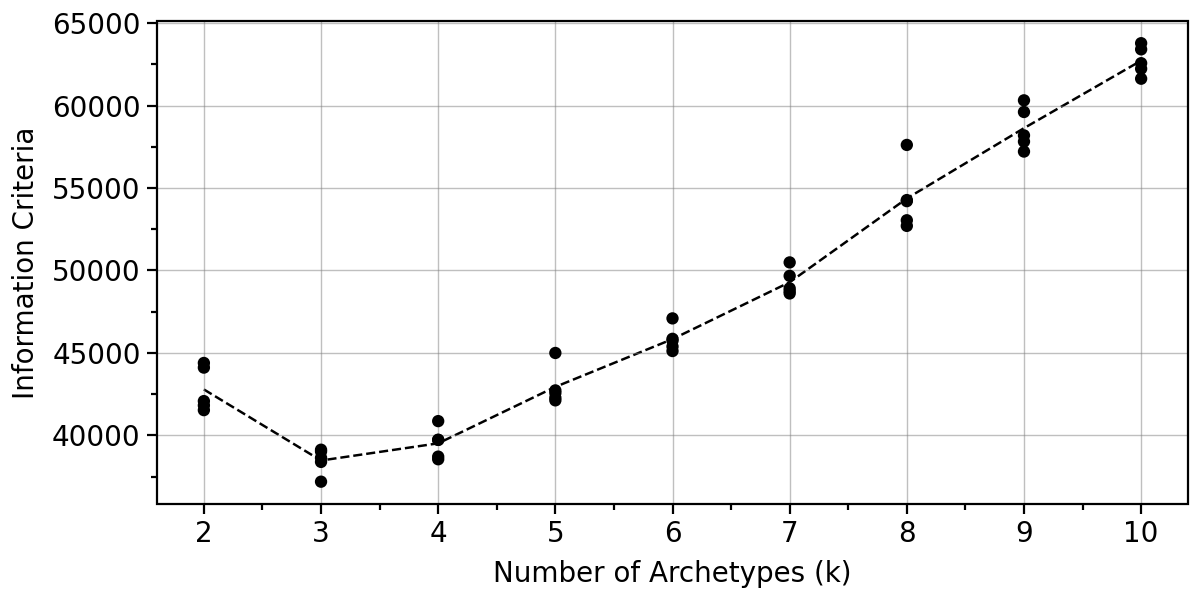

In [17]:
pt.plot_IC(adata)

This analysis suggests that the best choice is 4-6 archetypes. We decide to use 4 archetypes, as later analyses show that the 5th archetype introduces no new tasks.

In [18]:
n_archetypes = 4

To validate the archetype stability, we apply bootstrapping. We sample the data 25 times and run Archetypal Analysis (AA) on each sample. 

In [19]:
pt.compute_bootstrap_variance(adata=adata, n_bootstrap=50, n_archetypes_list=n_archetypes)

The positions of the archetypes and the mean variance per archetype and across all bootstrapped samples are stored in:

In [20]:
adata.uns["AA_bootstrap"][f"{n_archetypes}"]

,X_pca_0,X_pca_1,X_pca_2,X_pca_3,X_pca_4,X_pca_5,X_pca_6,archetype,iter,reference,mean_variance,variance_per_archetype
0,-4.819600,-3.522346,0.692504,-0.298517,0.253003,0.020091,0.129017,0,1,False,0.816198,0.313224
1,0.680280,3.923412,3.544204,-1.358980,0.422591,-0.048757,-0.140494,1,1,False,0.816198,1.288139
2,-1.406576,3.330772,-3.709808,1.039591,-0.445491,0.039480,-0.032219,2,1,False,0.816198,1.209803
3,6.301589,-2.510461,-0.713588,0.526952,-0.250739,-0.194268,0.113152,3,1,False,0.816198,0.453626
0,-3.826022,-3.558453,-1.151139,-1.099298,0.260374,0.405412,-0.132205,0,2,False,0.816198,0.313224
...,...,...,...,...,...,...,...,...,...,...,...,...
3,4.988849,-2.461560,2.761054,0.773643,0.055728,-0.150252,0.215823,3,50,False,0.816198,0.453626
0,-3.836658,-3.689509,-1.324489,-0.559538,0.177749,0.211792,-0.156322,0,0,True,0.816198,0.313224
1,-4.141594,2.784665,3.974659,1.716278,-0.345840,-0.237529,0.587640,1,0,True,0.816198,1.288139
2,1.816835,4.060271,-3.115339,-1.375853,0.306057,-0.114550,-0.472180,2,0,True,0.816198,1.209803


We visualize the bootstrapping results to show that the archetypes are mostly stable:

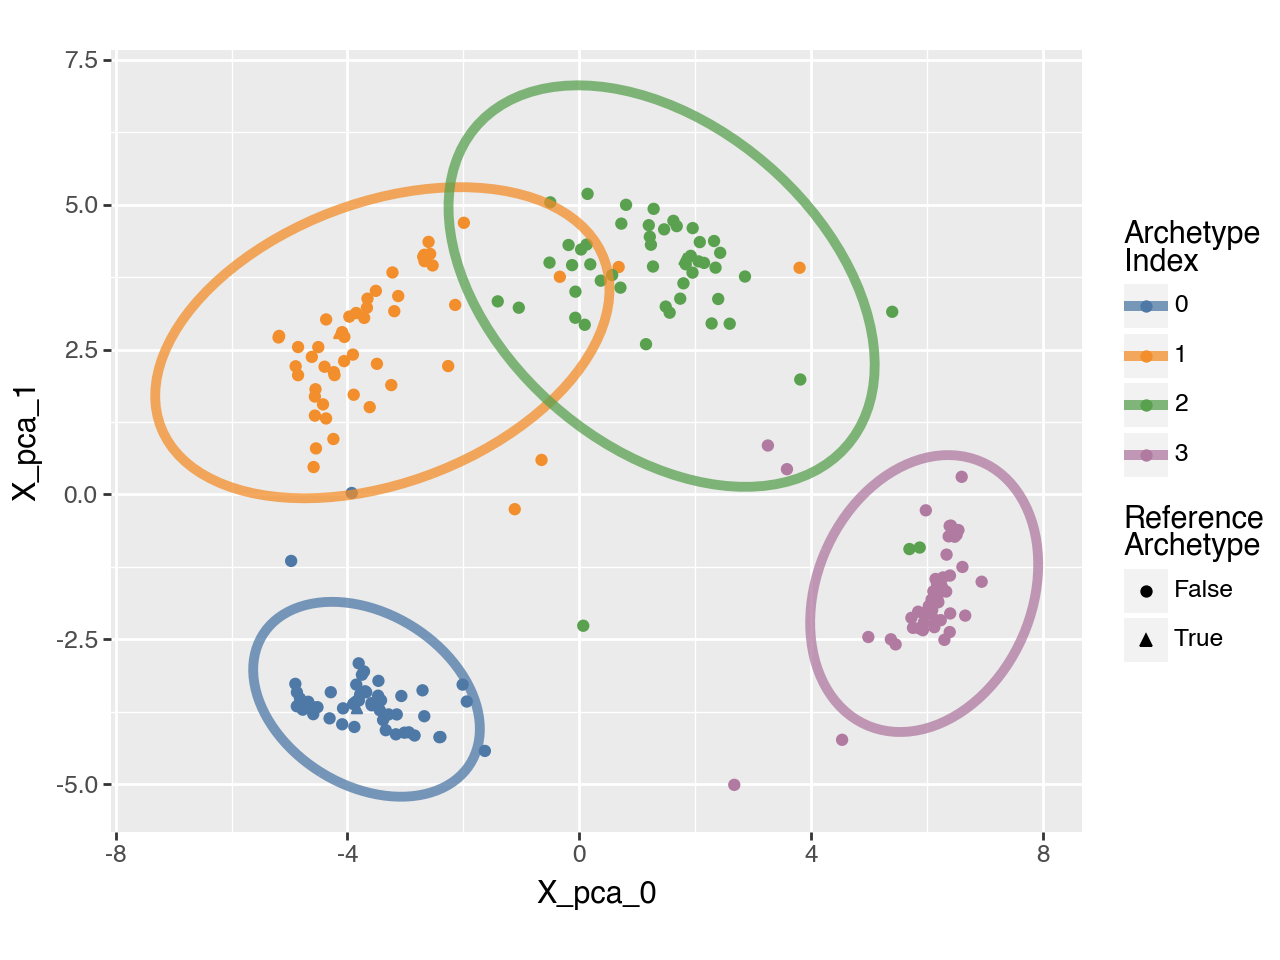

In [21]:
pt.plot_bootstrap_2D(adata, 4, show_contours=True)

## Archetype Analysis and Visualization of the Archetypes

Now that we've determined the number of archetypes, we can compute the four archetypes and save them to our AnnData object:

In [22]:
pt.compute_archetypes(adata, n_archetypes, archetypes_only=False)

The results are stored in adata.uns["AA_results"]. The archetypes can be found at:

In [23]:
adata.uns["AA_results"]["Z"]

array([[-3.8366582 , -3.6895092 , -1.3244889 , -0.5595384 ,  0.17774922,
         0.21179208, -0.15632214],
       [-4.1415944 ,  2.7846649 ,  3.9746592 ,  1.7162777 , -0.34584042,
        -0.23752858,  0.5876402 ],
       [ 1.8168349 ,  4.060271  , -3.1153386 , -1.3758527 ,  0.30605662,
        -0.11454965, -0.47217956],
       [ 6.103185  , -2.046956  ,  1.2110817 ,  0.55101615, -0.26233032,
        -0.133938  ,  0.16616504]], dtype=float32)

The RSS is also saved into "AA_results". We can manually check for the convergence as follows:

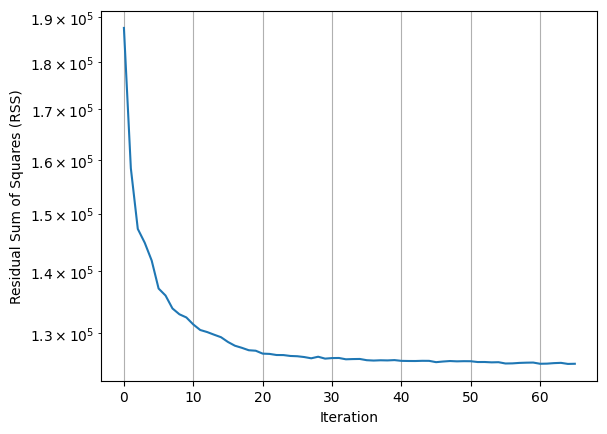

In [24]:
plt.plot(adata.uns["AA_results"]["RSS"])
plt.grid()
plt.xlabel("Iteration", y="Residual Sum of Squares (RSS)")
plt.ylabel("Residual Sum of Squares (RSS)")
plt.yscale("log")
plt.show()

We can visualize the polytope in both 2D and 3D with the coloring representing the disease status.
Alternatively, we can color the plot based on a gene with distinct expression across archetypes. For example, using the gene IFI27.

To visualize the polytope in 2D use the following function:

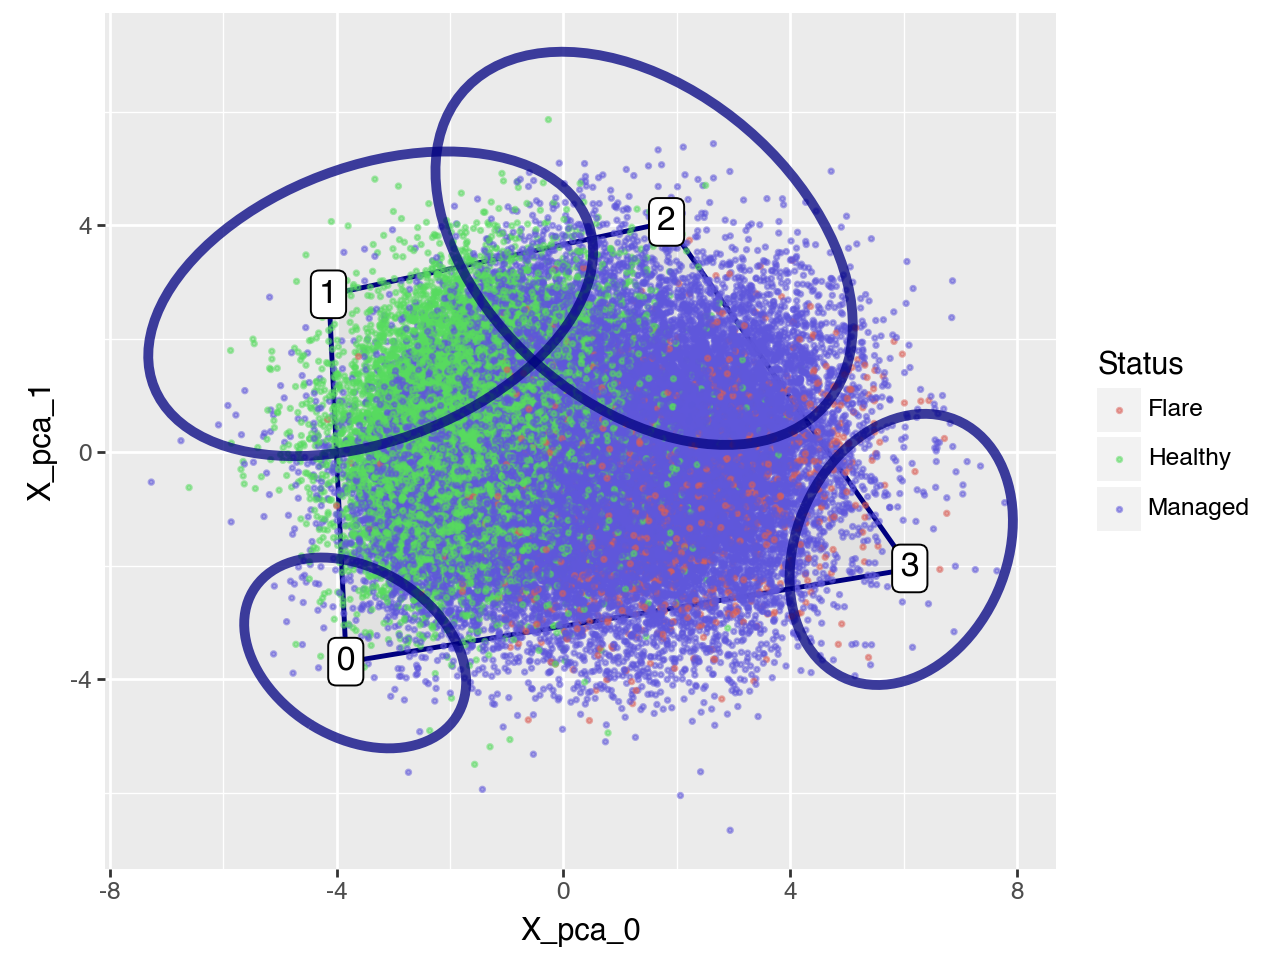

In [25]:
pt.plot_archetypes_2D(adata=adata, show_contours=True, color="Status", alpha=0.5, size=0.5)

## Identify representatives

To assign tasks to the archetypes, we need to identify cells that are representative of each archetype. To do this, we calculate cell weights for each archetype.

First, we calculate the weights for each cell based on its distance from the archetypes with a Radial Basis Function (RBF) kernel. The length scale of the RBF kernel is automatically set as half the median distance from the data centroid to the archetypes. However, this can also be manually adjusted if needed.

In [26]:
pt.compute_archetype_weights(adata=adata, mode="automatic")

Applied length scale is 3.05.


The resulting cell weights for e.g. archetype 3 are:

/Users/pschafer/Library/Application Support/hatch/env/virtual/partipy/U65dndfd/docs/lib/python3.11/site-packages/plotnine/scales/scale_size.py:46: PlotnineWarning: Using size for a discrete variable is not advised.


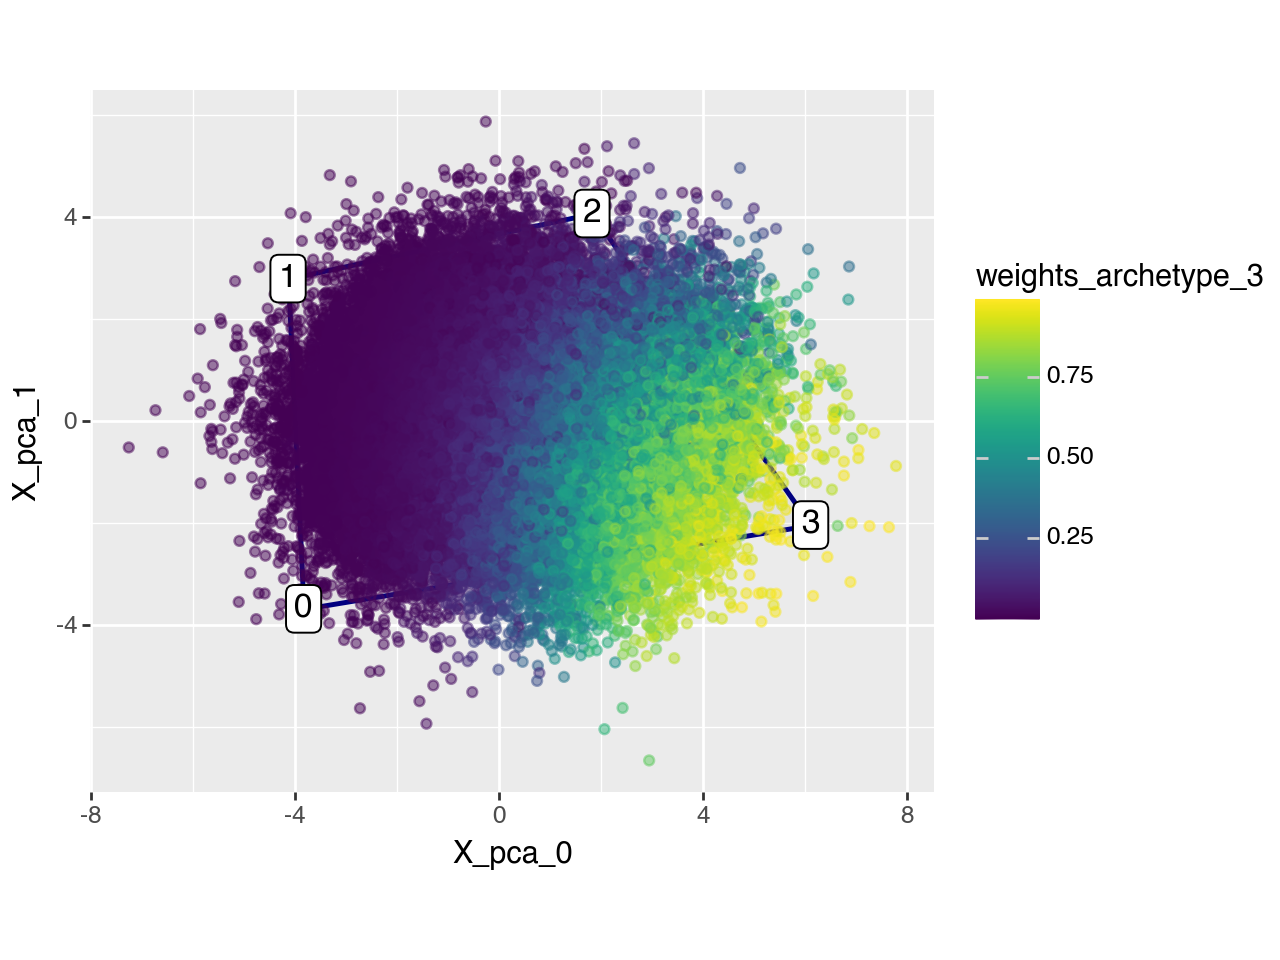

In [27]:
arch_idx = 3
adata.obs[f"weights_archetype_{arch_idx}"] = adata.obsm["cell_weights"][:, arch_idx]
pt.plot_archetypes_2D(adata=adata, color=f"weights_archetype_{arch_idx}", alpha=0.5)

## Enrichment Metadata

With the weights we can now calculate enrichment of interest. Since we have different cell status associated with healthy and disease, we want first to check the enrichment by the disease state and find our archetypes of interest.

meta_enrichment() calcualtes the enrichment of any specified metadata stored in .obs. 

In [28]:
status_enrichment = pt.compute_meta_enrichment(adata=adata, meta_col="Status")
status_enrichment

,Flare,Managed,Healthy
0,0.239499,0.303645,0.456856
1,0.158130,0.296605,0.545264
2,0.323126,0.354287,0.322587
3,0.558370,0.369380,0.072250


We find ncM with the "Flare" status enriched at an archetype. These results can be visualized in multiple ways:

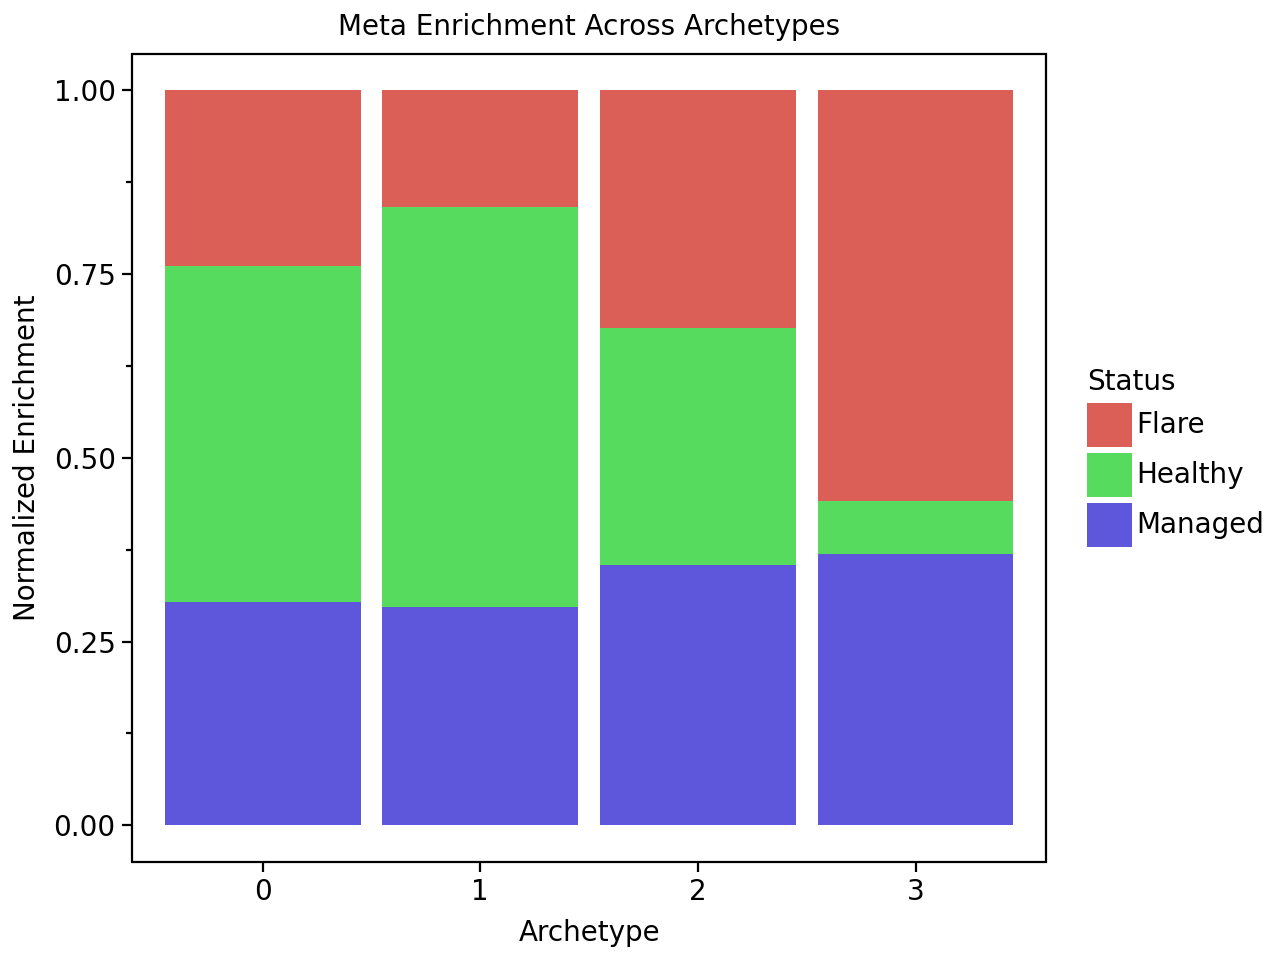

In [29]:
pt.barplot_meta_enrichment(status_enrichment, meta="Status")

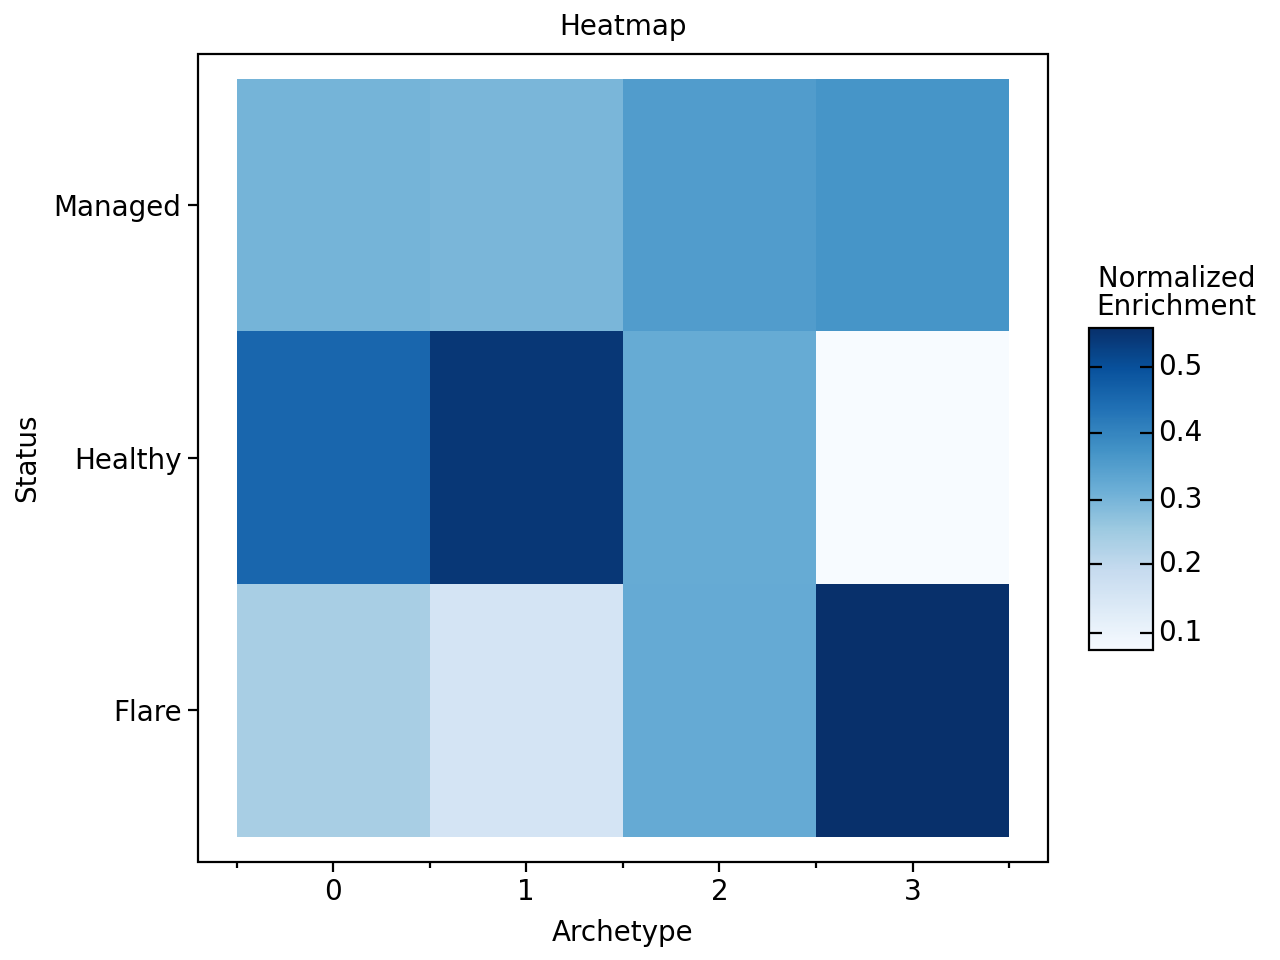

In [30]:
pt.heatmap_meta_enrichment(status_enrichment, meta="Status")

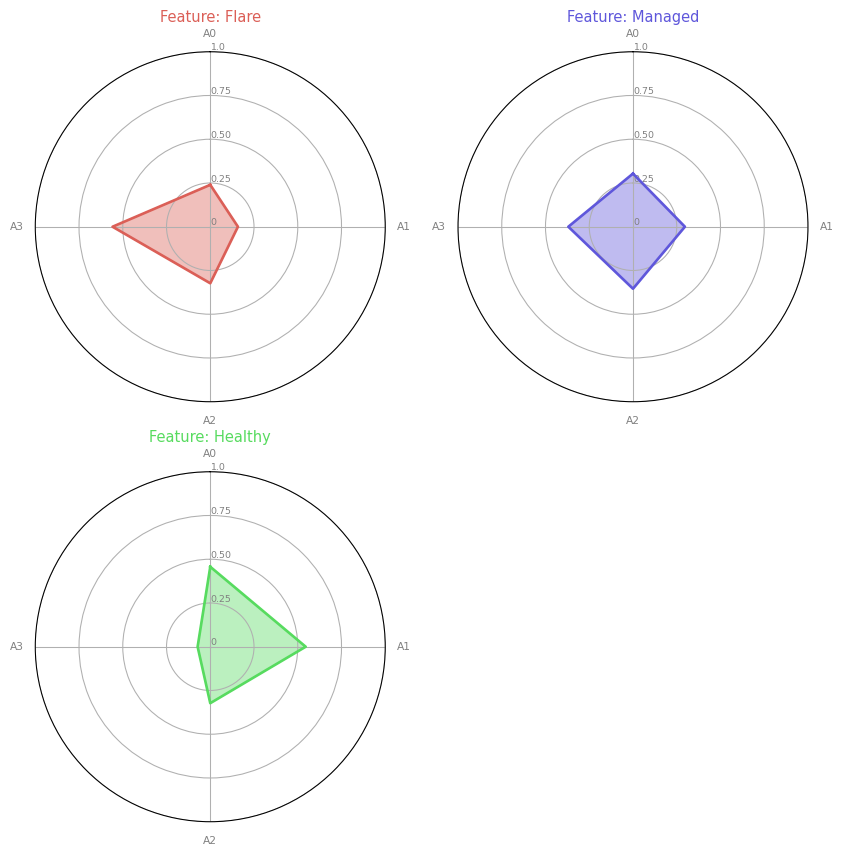

In [31]:
pt.radarplot_meta_enrichment(status_enrichment)

## Functional Enrichment MSigDB

Next, we compute the archetypes "gene expression" using the z-scaled gene expression data and cell weights to observe differences in gene expression across the archetypes:

In [32]:
archetype_expression = pt.compute_archetype_expression(adata=adata, layer="z_scaled")
archetype_expression.iloc[:, 20:25]

,TNFRSF4,SDF4,B3GALT6,C1QTNF12,ENSG00000260179.1
0,-264.061709,-377.368568,-214.181151,-389.241108,-354.064726
1,-89.521190,-17.347482,-13.881577,-157.516736,-158.725931
2,-188.251374,153.987461,-101.424069,-253.985357,-239.223151
3,-247.467287,240.728588,-90.772737,-254.739362,-218.903047


For functional enrichment, we use Decoupler with Gene Ontology (GO) biological processes. While other collections can be used, it’s recommended to choose those with less broad categories to avoid non-significant results.

We begin by loading the MSigDB resource and filtering for the GO biological processes collection:

In [33]:
msigdb_raw = dc.op.resource("MSigDB")
msigdb = msigdb_raw[msigdb_raw["collection"]=="go_biological_process"]
msigdb = msigdb[~msigdb.duplicated(["geneset", "genesymbol"])]
msigdb = msigdb.rename(columns={"geneset": "source", "genesymbol": "target"})
msigdb

,target,collection,source
,,,
73,A1CF,go_biological_process,GOBP_MRNA_METABOLIC_PROCESS
78,A1CF,go_biological_process,GOBP_EMBRYO_IMPLANTATION
84,A1CF,go_biological_process,GOBP_MACROMOLECULE_CATABOLIC_PROCESS
87,A1CF,go_biological_process,GOBP_MRNA_MODIFICATION
88,A1CF,go_biological_process,GOBP_RNA_PROCESSING
...,...,...,...
5522215,ZZZ3,go_biological_process,GOBP_PROTEIN_ACYLATION
5522223,ZZZ3,go_biological_process,GOBP_HISTONE_H3_ACETYLATION
5522241,ZZZ3,go_biological_process,GOBP_REGULATION_OF_MULTICELLULAR_ORGANISMAL_DE...


Next, we run ULM from decoupler on the pseudobulk data using the filtered MSigDB resource. The resulting estimated enrichment scores and p-values are saved in acts_ulm_est and acts_ulm_est_p:

In [34]:
acts_ulm_est, acts_ulm_est_p = dc.mt.ulm(data=archetype_expression,
                                         net=msigdb)

acts_ulm_est

,GOBP_10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS,GOBP_2FE_2S_CLUSTER_ASSEMBLY,GOBP_2_OXOGLUTARATE_METABOLIC_PROCESS,GOBP_3_PHOSPHOADENOSINE_5_PHOSPHOSULFATE_METABOLIC_PROCESS,GOBP_3_UTR_MEDIATED_MRNA_DESTABILIZATION,GOBP_3_UTR_MEDIATED_MRNA_STABILIZATION,GOBP_4FE_4S_CLUSTER_ASSEMBLY,GOBP_5S_CLASS_RRNA_TRANSCRIPTION_BY_RNA_POLYMERASE_III,GOBP_5_PHOSPHORIBOSE_1_DIPHOSPHATE_METABOLIC_PROCESS,GOBP_7_METHYLGUANOSINE_CAP_HYPERMETHYLATION,...,GOBP_XENOBIOTIC_TRANSPORT,GOBP_XENOBIOTIC_TRANSPORT_ACROSS_BLOOD_BRAIN_BARRIER,GOBP_XENOPHAGY,GOBP_XMP_METABOLIC_PROCESS,GOBP_XYLULOSE_5_PHOSPHATE_METABOLIC_PROCESS,GOBP_ZINC_ION_IMPORT_ACROSS_PLASMA_MEMBRANE,GOBP_ZINC_ION_IMPORT_INTO_ORGANELLE,GOBP_ZINC_ION_TRANSPORT,GOBP_ZYMOGEN_ACTIVATION,GOBP_ZYMOGEN_INHIBITION
0,0.258536,0.758668,0.002049,-0.358584,-4.316704,-2.576301,1.019621,0.376950,0.441782,0.950732,...,-0.348379,0.244865,-3.067895,-0.079303,-0.198100,0.349063,0.478610,0.818498,-2.552265,-0.211736
1,-0.208943,-2.025886,-0.897021,-0.704981,4.739514,3.368617,-1.065959,0.502783,0.032781,-3.005890,...,-0.433812,0.138905,1.097764,0.071309,-1.461351,0.579849,0.486073,0.447022,-3.199352,-0.694464
2,0.412722,2.544934,1.602430,0.674487,3.387806,3.569128,1.421148,0.841429,1.659017,2.393291,...,-1.324418,-0.546883,2.129476,1.896264,2.280694,0.484246,0.085466,0.495354,1.596746,0.614891
3,0.139663,1.241686,0.706767,0.509890,0.171898,0.481228,0.761676,0.455834,0.538513,2.406543,...,-0.888543,-0.587298,2.250713,-0.401029,0.649361,-0.097406,0.177126,0.218798,4.020262,1.791385


To identify the top enriched processes for each archetype, we extract the top 20 processes and order them in descending order:

In [35]:
top_processes = pt.extract_enriched_processes(est=acts_ulm_est, 
                                                     pval=acts_ulm_est_p, 
                                                     order="desc", 
                                                     n=20, 
                                                     p_threshold=0.05)

For example, for the archetype that is enriched in “Flare,” we observe an enrichment of processes related to the immune response to viruses and the response to interferon.

In [36]:
top_processes[arch_idx].round(2)

,Process,0,1,2,3,specificity
0,GOBP_NEGATIVE_REGULATION_OF_VIRAL_GENOME_REPLI...,-17.66,-13.59,-0.16,29.28,29.44
1,GOBP_NEGATIVE_REGULATION_OF_VIRAL_PROCESS,-19.90,-12.54,3.38,28.63,25.26
2,GOBP_DEFENSE_RESPONSE_TO_SYMBIONT,-19.31,-8.47,4.98,27.22,22.24
3,GOBP_DEFENSE_RESPONSE_TO_OTHER_ORGANISM,-23.50,-6.28,14.64,26.46,11.83
4,GOBP_INNATE_IMMUNE_RESPONSE,-21.85,-7.08,13.34,26.11,12.77
5,GOBP_BIOLOGICAL_PROCESS_INVOLVED_IN_INTERSPECI...,-23.96,-4.75,17.58,25.70,8.12
6,GOBP_RESPONSE_TO_VIRUS,-19.02,-6.66,7.25,25.47,18.22
7,GOBP_DEFENSE_RESPONSE,-24.39,-5.13,16.30,24.69,8.39
8,GOBP_IMMUNE_RESPONSE,-24.32,-5.35,18.15,23.78,5.63
9,GOBP_REGULATION_OF_VIRAL_PROCESS,-19.40,-9.28,8.26,23.63,15.37


On the other hand, for the archetype that is enriched in healthy, we see task of upkeeping homeostasis and normal cellular function in the cells.

In [37]:
top_processes[1].round(2)

,Process,0,1,2,3,specificity
0,GOBP_CYTOPLASMIC_TRANSLATION,3.41,15.25,32.46,-22.99,-17.22
1,GOBP_POSITIVE_REGULATION_OF_RNA_METABOLIC_PROCESS,-2.95,14.73,7.88,2.58,6.85
2,GOBP_POSITIVE_REGULATION_OF_MACROMOLECULE_BIOS...,-2.56,13.78,8.84,2.27,4.94
3,GOBP_POSITIVE_REGULATION_OF_TRANSCRIPTION_BY_R...,-4.05,12.55,5.19,1.34,7.36
4,GOBP_NEGATIVE_REGULATION_OF_BIOSYNTHETIC_PROCESS,-2.96,11.82,6.22,1.39,5.60
5,GOBP_NEGATIVE_REGULATION_OF_NUCLEOBASE_CONTAIN...,-2.53,11.82,5.31,1.21,6.51
6,GOBP_CHROMATIN_ORGANIZATION,3.45,11.19,2.47,-0.43,7.74
7,GOBP_NEGATIVE_REGULATION_OF_RNA_BIOSYNTHETIC_P...,-2.56,10.62,4.02,1.00,6.59
8,GOBP_MRNA_METABOLIC_PROCESS,2.75,10.45,8.22,3.24,2.23
9,GOBP_PEPTIDE_BIOSYNTHETIC_PROCESS,2.21,10.09,24.27,-7.18,-14.18


To identify processes specific to a particular archetype, meaning they are in the top enriched processes of one archetype, we can filter for the highest specificity score, by apply the following function:

In [38]:
specific_processes = pt.extract_specific_processes(est=acts_ulm_est,
                                                          pval=acts_ulm_est_p, 
                                                          n=10,
                                                          p_threshold=0.05)

specific_processes[2].round(2)

,Process,0,1,2,3,specificity
0,GOBP_PEPTIDE_ANTIGEN_ASSEMBLY_WITH_MHC_CLASS_I...,-26.78,-18.54,46.66,7.32,39.35
1,GOBP_PEPTIDE_ANTIGEN_ASSEMBLY_WITH_MHC_PROTEIN...,-24.94,-17.34,43.00,7.79,35.21
2,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EX...,-23.08,-17.33,37.86,9.54,28.32
3,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_PE...,-21.47,-15.77,34.82,9.35,25.47
4,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EX...,-23.19,-16.52,34.92,11.66,23.26
5,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EX...,-22.01,-15.61,32.40,11.43,20.98
6,GOBP_CYTOPLASMIC_TRANSLATION,3.41,15.25,32.46,-22.99,17.22
7,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_PE...,-20.60,-14.38,28.91,12.14,16.77
8,GOBP_IMMUNOGLOBULIN_PRODUCTION_INVOLVED_IN_IMM...,-12.14,-6.21,20.31,4.04,16.27
9,GOBP_DENDRITIC_CELL_ANTIGEN_PROCESSING_AND_PRE...,-13.64,-7.78,20.77,5.38,15.39


For visualization we can plot the obtained results:

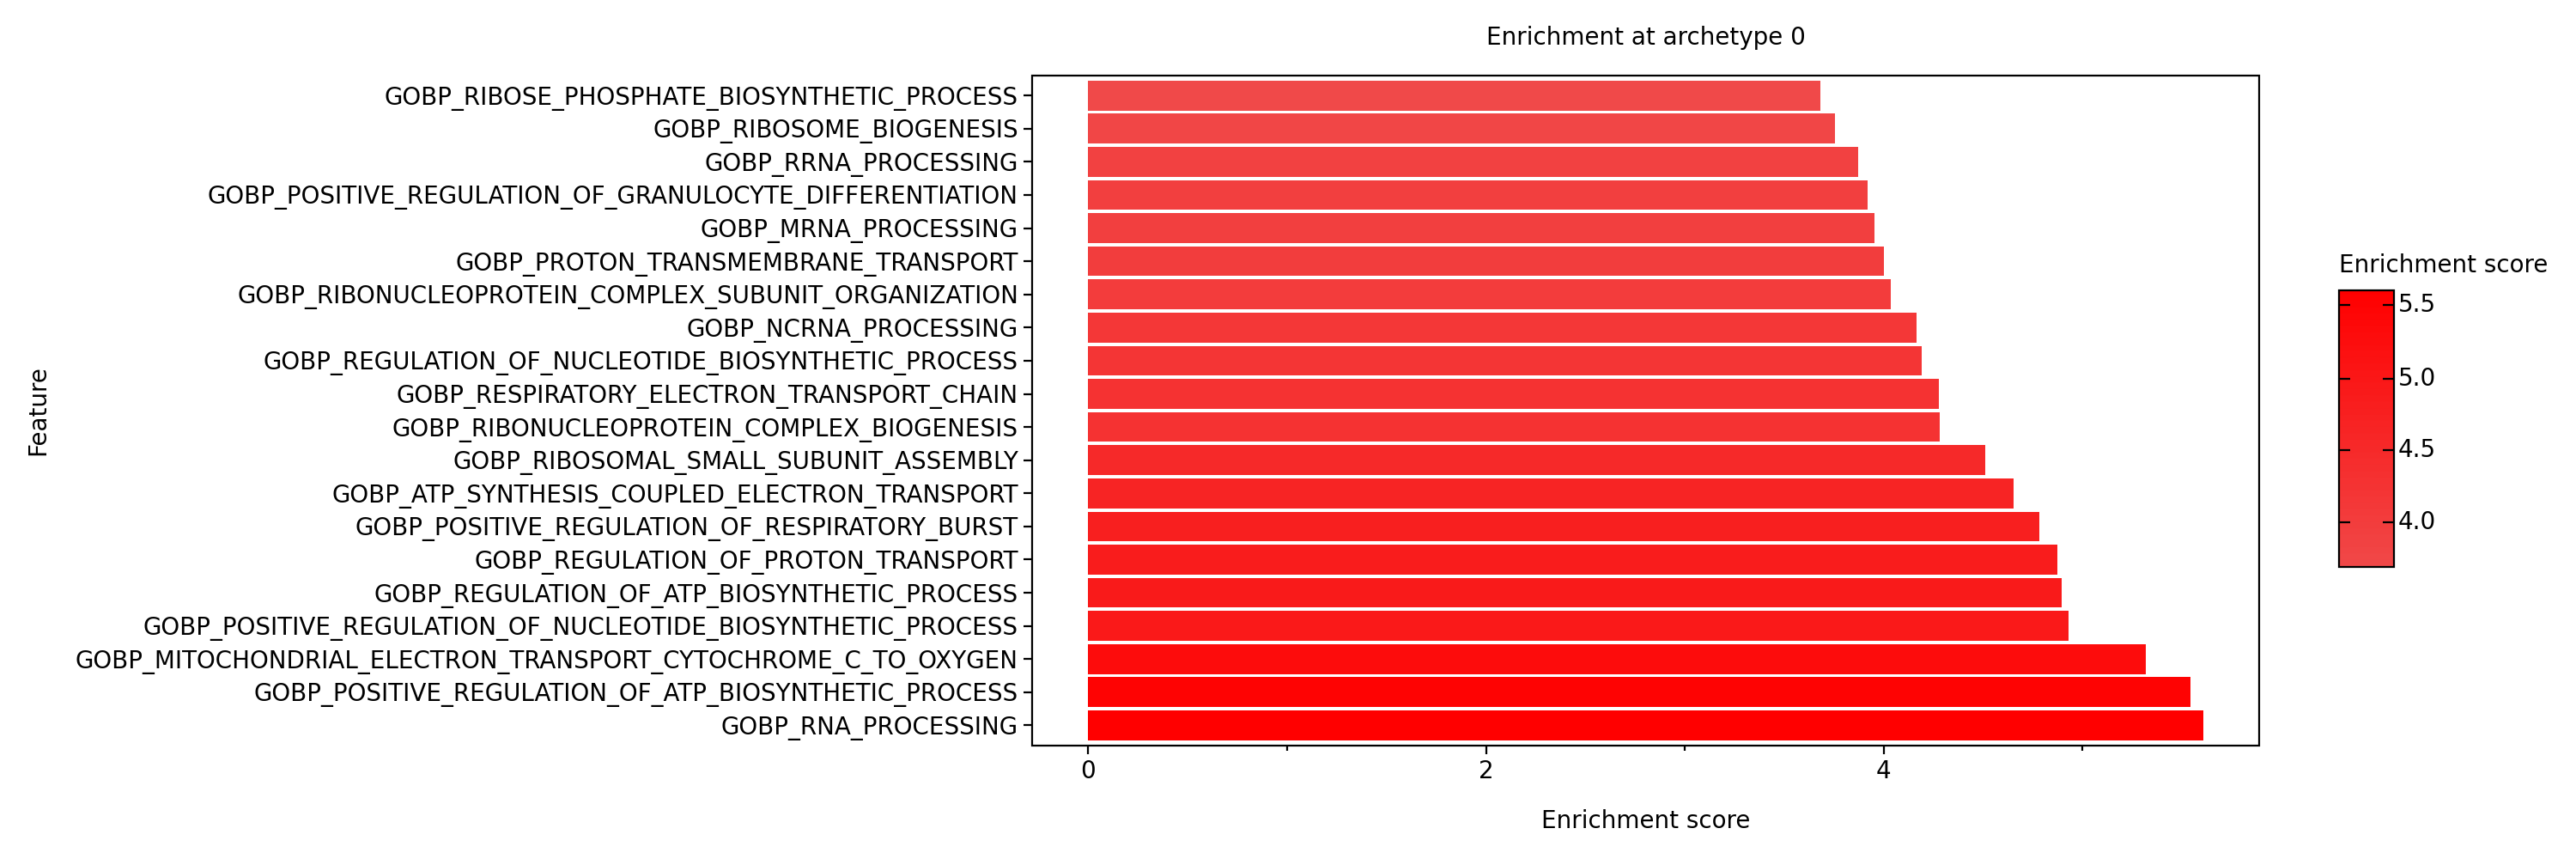

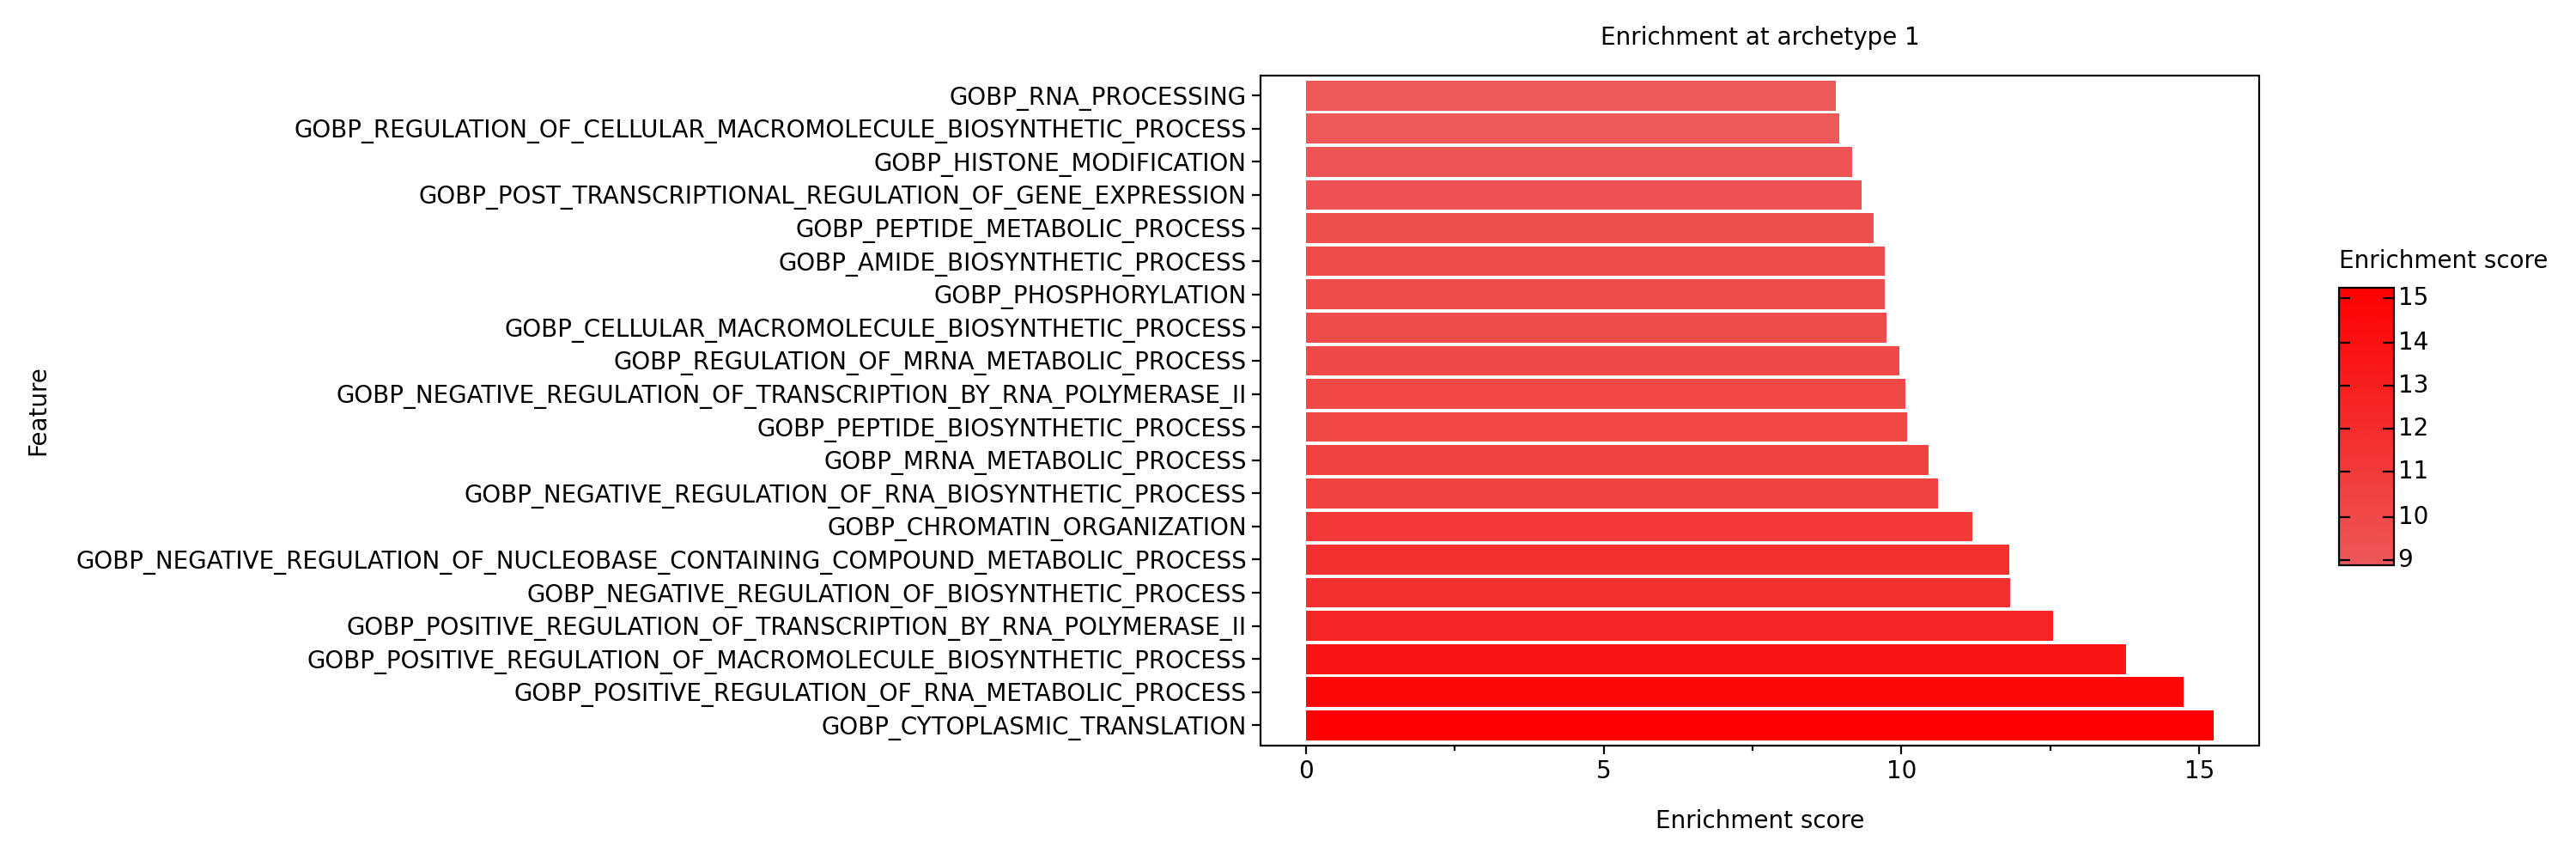

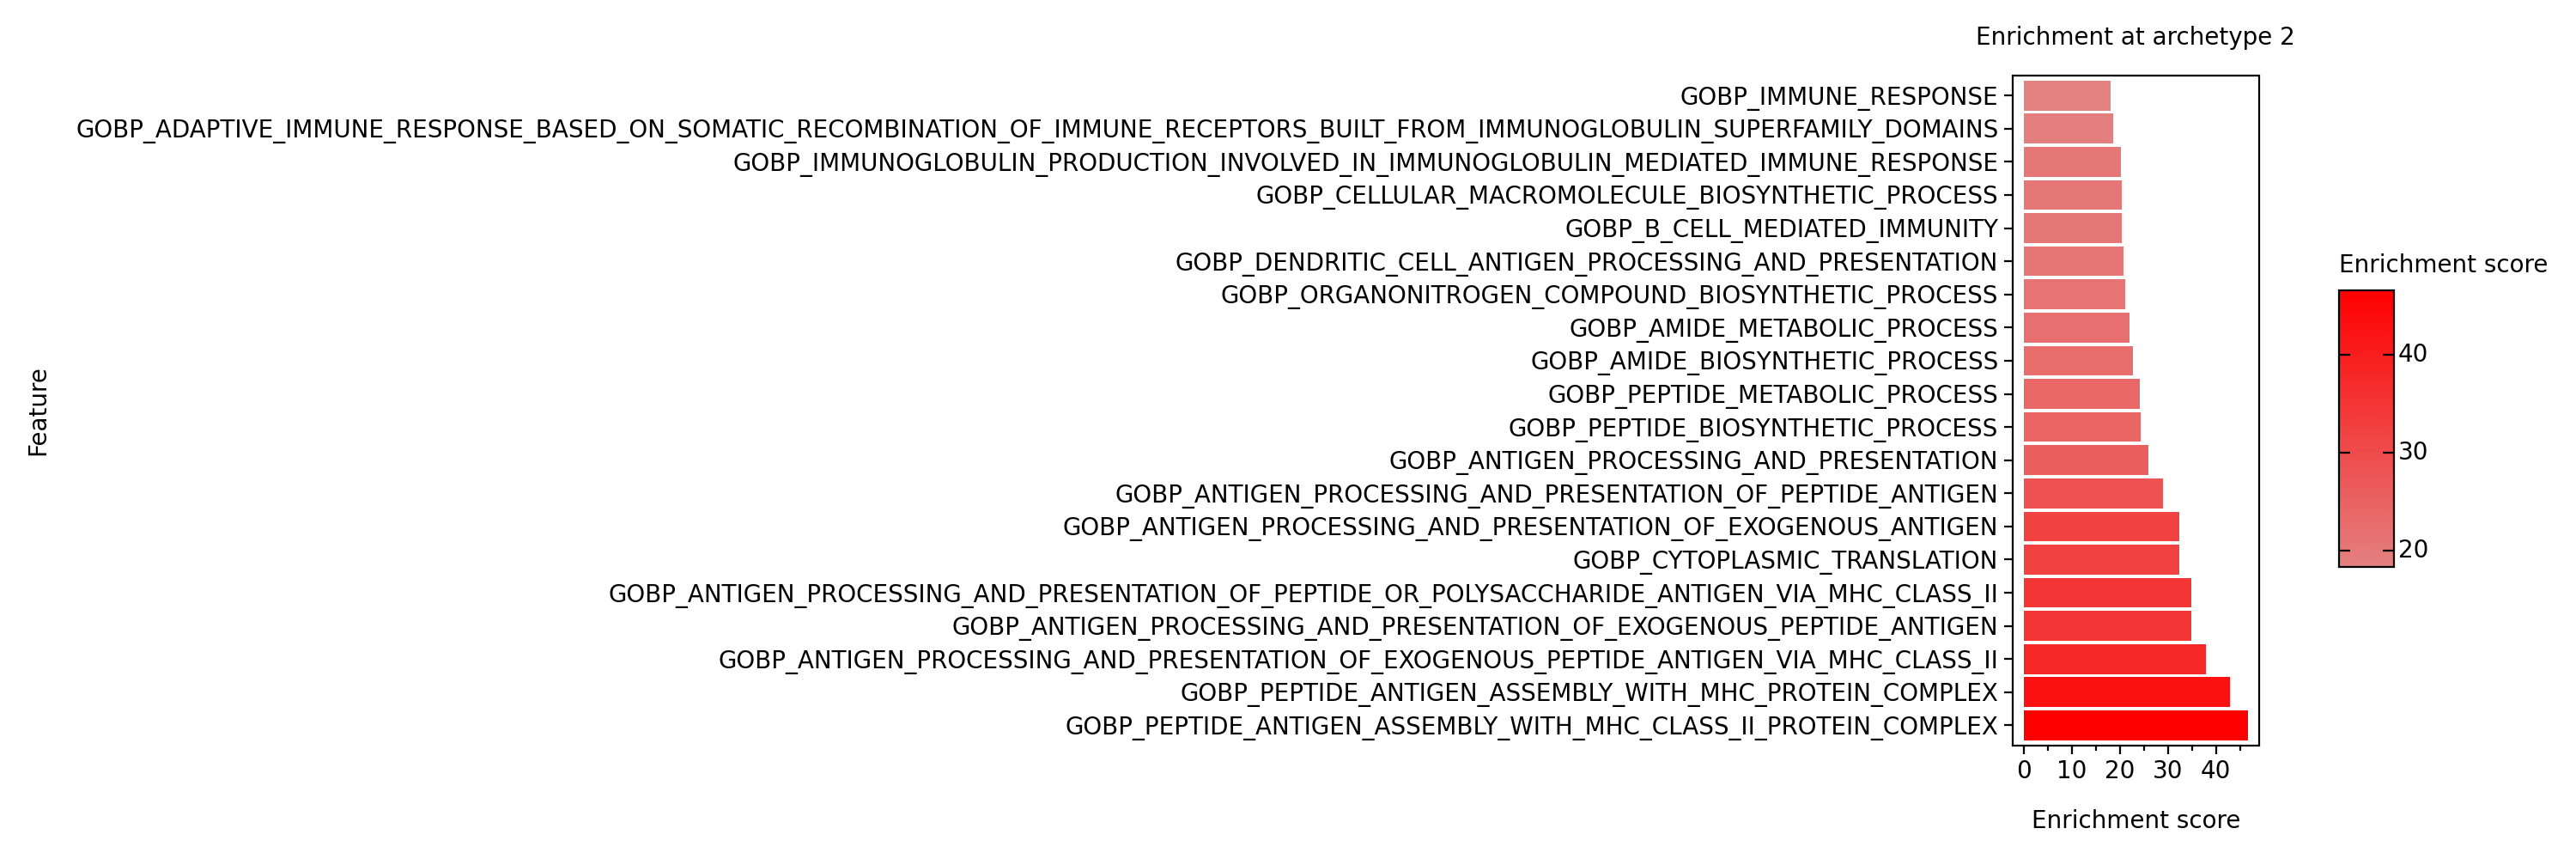

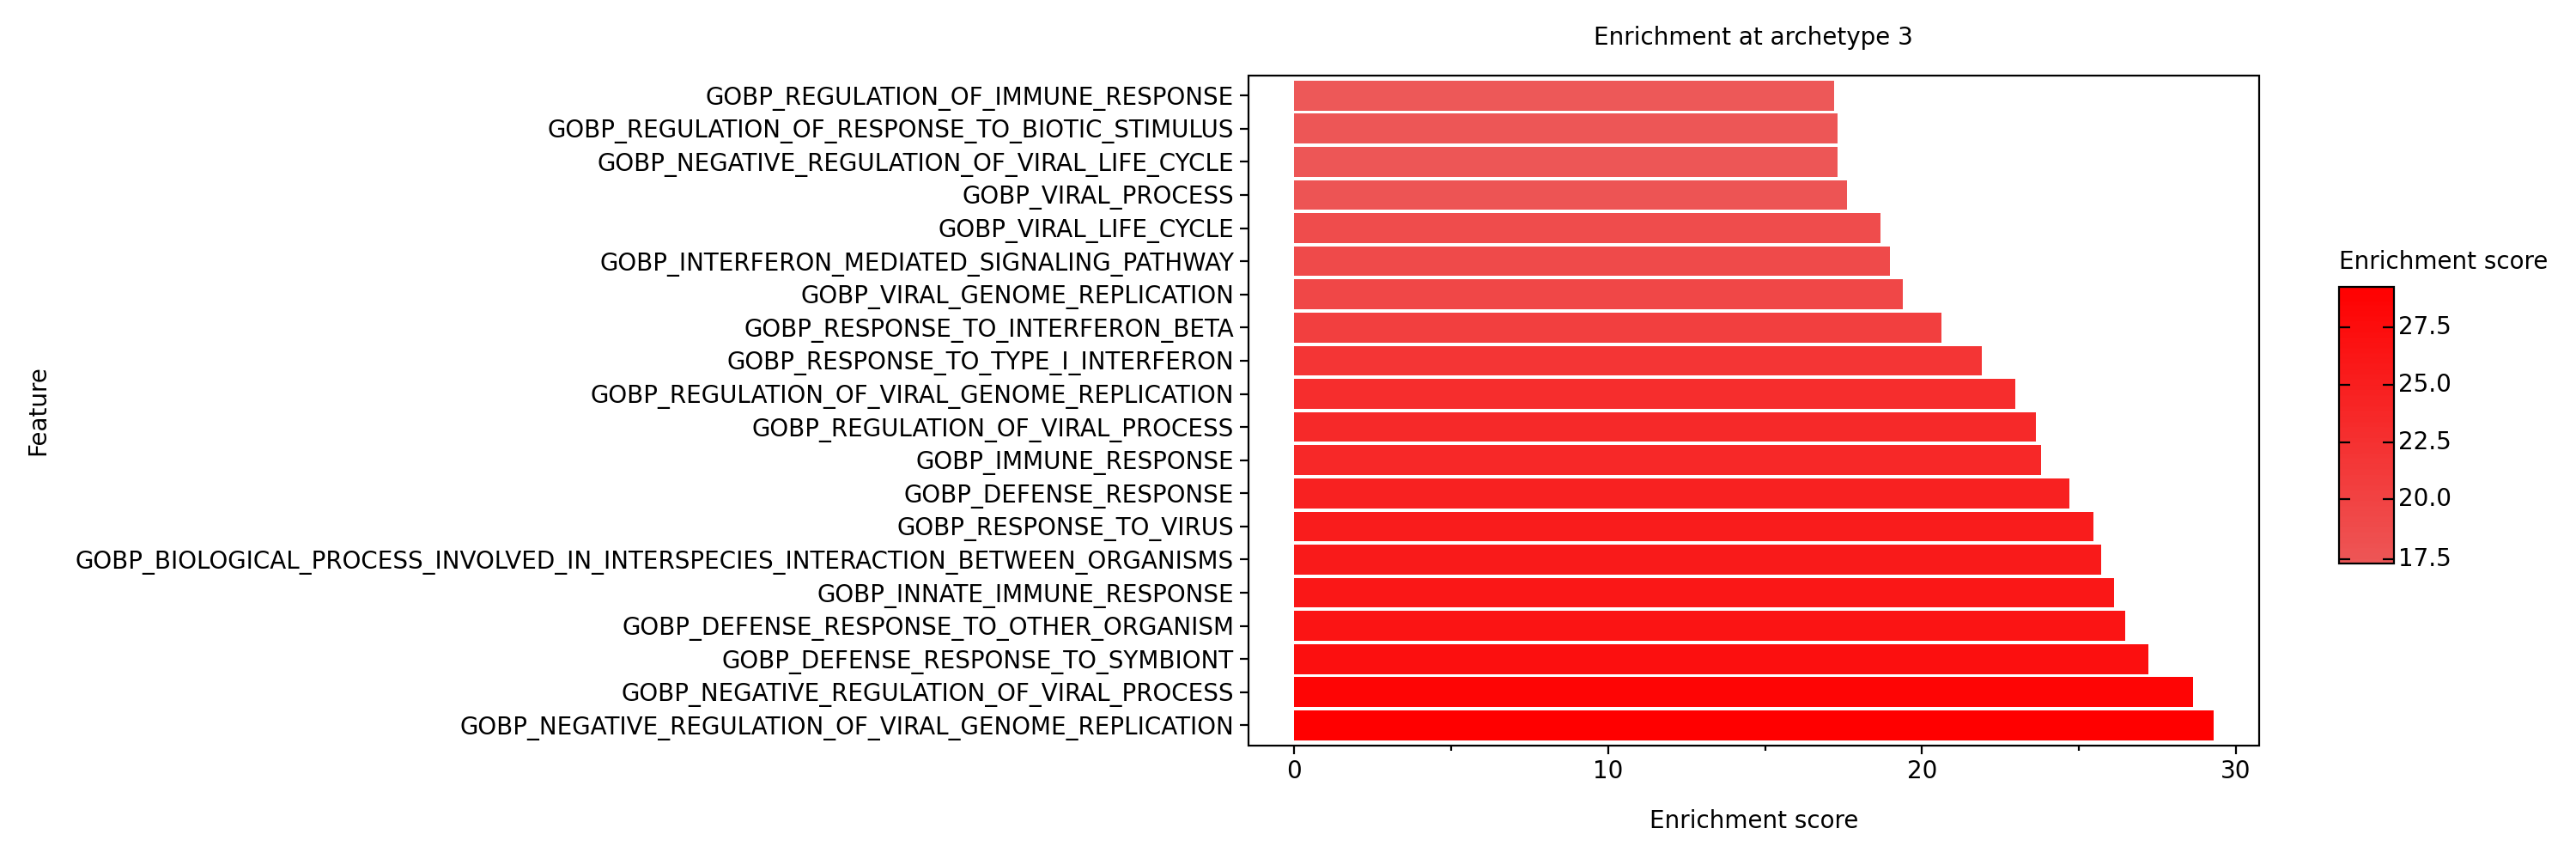

In [39]:
pt.barplot_functional_enrichment(top_processes)

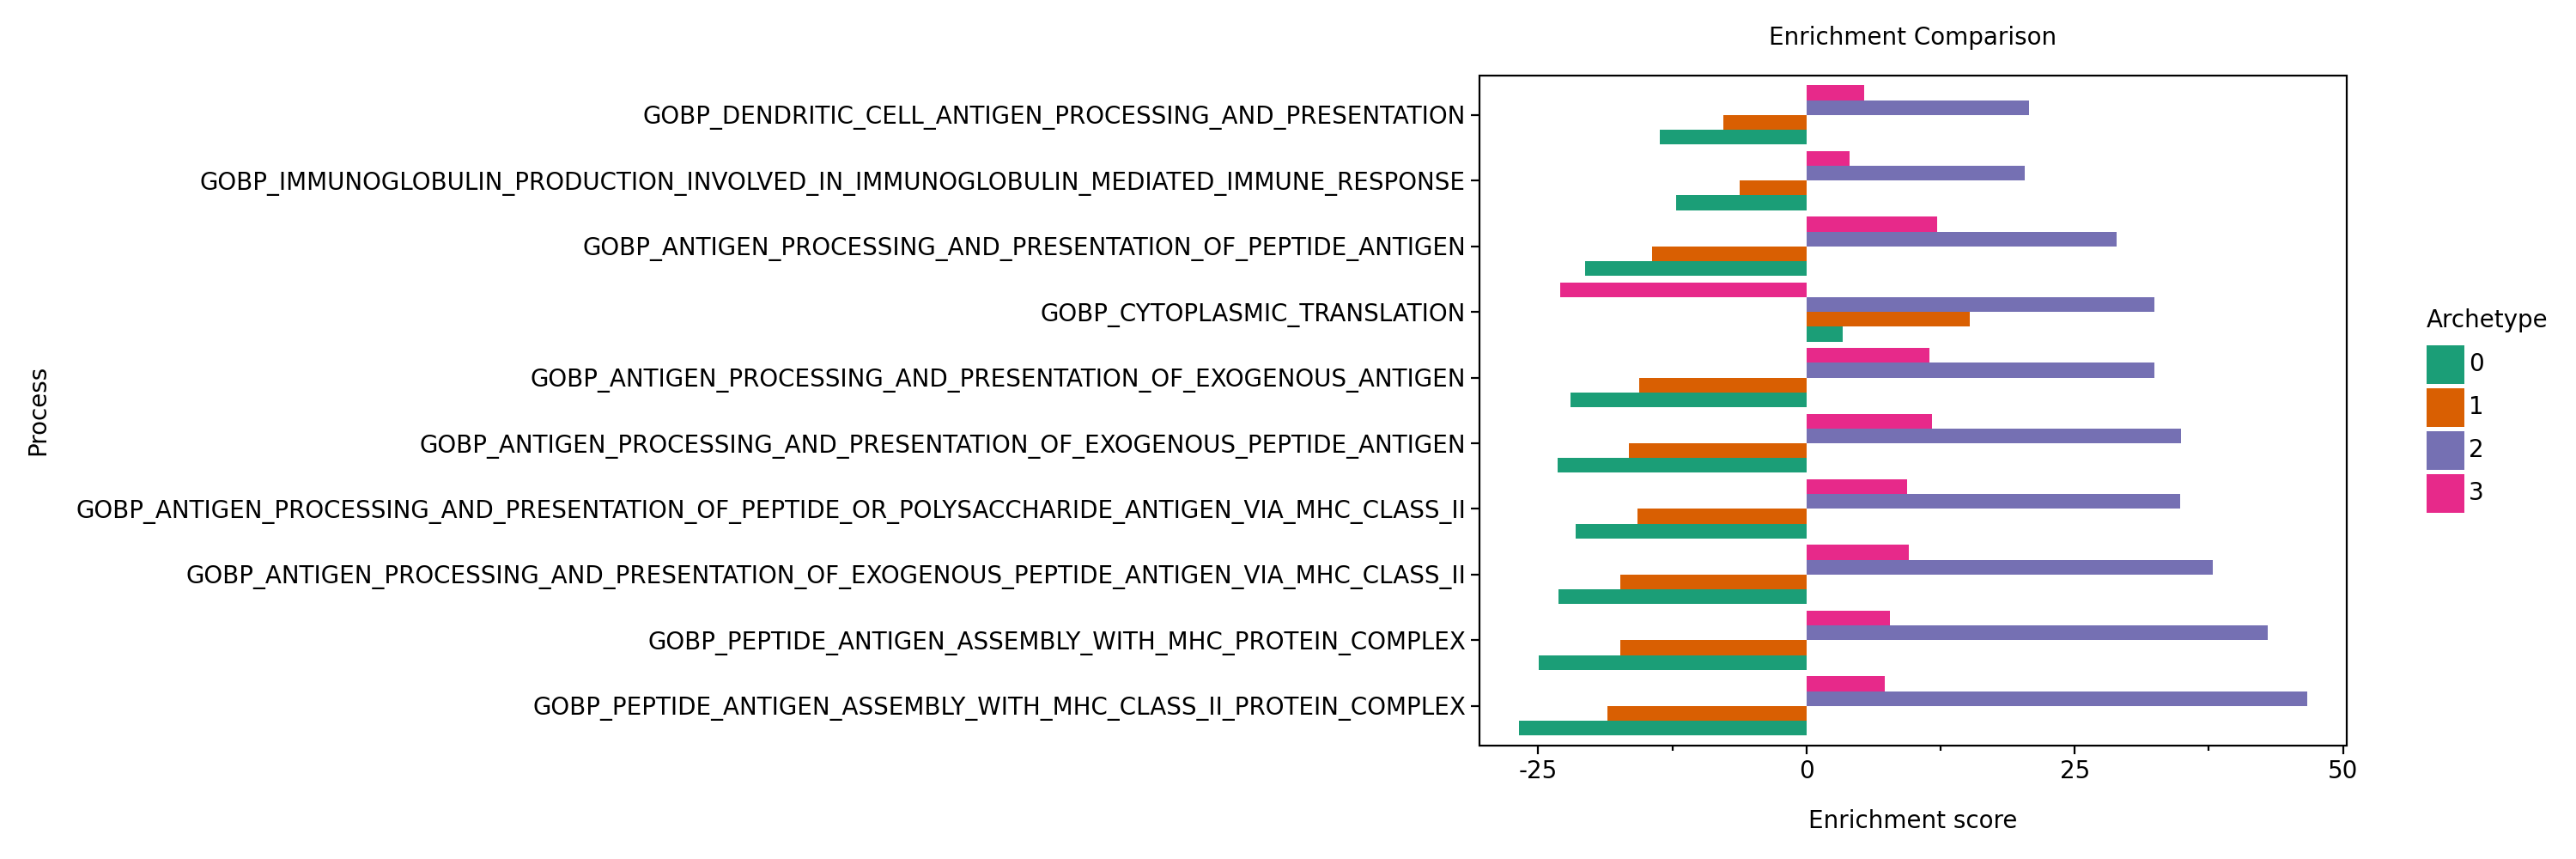

In [40]:
pt.barplot_enrichment_comparison(specific_processes[2]) + pn.theme(figure_size=(15, 5))

## Session Info

In [41]:
import session_info2
print(session_info2.session_info(dependencies=True))

plotnine	0.14.5
pandas	2.2.3
scanpy	1.11.2
matplotlib	3.10.3
partipy	0.0.1
decoupler	2.0.3
anndata	0.11.4
numpy	2.2.6
----	----
tqdm	4.67.1
h5py	3.13.0
legacy-api-wrap	1.4.1
kiwisolver	1.4.8
cattrs	25.1.0
cffi	1.17.1
certifi	2025.4.26 (2025.04.26)
six	1.17.0
defusedxml	0.7.1
pyzmq	26.4.0
pytz	2025.2
executing	2.2.0
appnope	0.1.4
pycparser	2.22
attrs	25.3.0
Pygments	2.19.1
setuptools	80.9.0
cloudpickle	3.1.1
adjustText	1.3.0
python-dateutil	2.9.0.post0
docrep	0.3.2
seaborn	0.13.2
cycler	0.12.1
matplotlib-inline	0.1.7
ipywidgets	8.1.7
dcor	0.6
natsort	8.4.0
urllib3	2.4.0
sphinxcontrib-bibtex	2.6.3
sphinxcontrib-jsmath	1.0.1
sphinxcontrib-qthelp	2.0.0
importlib_metadata	8.7.0
comm	0.2.2
prompt_toolkit	3.0.51
narwhals	1.41.0
sphinxcontrib-devhelp	2.0.0
dask	2024.11.2
llvmlite	0.44.0
requests	2.32.3
asttokens	3.0.0
patsy	1.0.1
charset-normalizer	3.4.2
typing_extensions	4.13.2
jupyter_client	8.6.3
legendkit	0.3.5
traitlets	5.14.3
idna	3.10
Deprecated	1.2.18
plotly	6.1.2
psutil	7.0.0
url-norm

/Users/pschafer/Library/Application Support/hatch/env/virtual/partipy/U65dndfd/docs/lib/python3.11/site-packages/session_info2/__init__.py:124: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
